In [1]:
!pip install Pillow albumentations matplotlib torch torchvision ultralytics tqdm wandb pycocotools torchmetrics

In [1]:
import glob
from xml.etree import ElementTree as ET
import os
import shutil
from PIL import Image
from pathlib import Path
import pickle
import torchvision.transforms.v2


import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
import ultralytics
from albumentations.pytorch.transforms import ToTensorV2
from matplotlib.patches import Rectangle
from torch import nn
from torchvision.models import ResNet50_Weights
from tqdm.notebook import tqdm
import logging
import time
import pandas as pd
import yaml


In [2]:
from dotenv import load_dotenv
import wandb

load_dotenv()

WANDB_API_KEY = os.getenv("WANDB_API_KEY")
WANDB_PROJECT = os.getenv("WANDB_PROJECT", "gp5")
WANDB_ENTITY = os.getenv("WANDB_ENTITY")

In [3]:
def stop_logging():
    logger = logging.getLogger()
    for handler in logger.handlers:
        handler.flush()
        handler.close()
        logger.removeHandler(handler)

def new_log_file(prefix="cnn"):
    stop_logging()
    timestamp = str(time.time()).replace('.', '_')
    log_file = f'{prefix}_{timestamp}.log'
    logging.basicConfig(
        filename=log_file,
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(message)s',
        force=True
    )
    logging.info("Начал логгировать новый запуск")
    return log_file

In [4]:

import sys
print(sys.executable)
print(sys.version)

c:\Users\Polina\AppData\Local\Programs\Python\Python311\python.exe
3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]


In [5]:
wandb.login(key=WANDB_API_KEY)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\Polina\_netrc
wandb: Currently logged in as: gigantina-ru (gigantina-ru-hse-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

Правильно раскидываем файлики по папочкам

In [6]:
'''source_dir = "dataset/train"
images_dir = os.path.join(source_dir, "images")
texts_dir = os.path.join(source_dir, "labels")

os.makedirs(images_dir, exist_ok=True)
os.makedirs(texts_dir, exist_ok=True)

for filename in os.listdir(source_dir):
    filepath = os.path.join(source_dir, filename)
    ext = os.path.splitext(filename)[1].lower()

    if ext == ".jpg":
        shutil.move(filepath, os.path.join(images_dir, filename))
    elif ext == ".txt":
        shutil.move(filepath, os.path.join(texts_dir, filename))'''

'source_dir = "dataset/train"\nimages_dir = os.path.join(source_dir, "images")\ntexts_dir = os.path.join(source_dir, "labels")\n\nos.makedirs(images_dir, exist_ok=True)\nos.makedirs(texts_dir, exist_ok=True)\n\nfor filename in os.listdir(source_dir):\n    filepath = os.path.join(source_dir, filename)\n    ext = os.path.splitext(filename)[1].lower()\n\n    if ext == ".jpg":\n        shutil.move(filepath, os.path.join(images_dir, filename))\n    elif ext == ".txt":\n        shutil.move(filepath, os.path.join(texts_dir, filename))'

In [7]:

# for dir in ['dataset/train/images', 'dataset/train/labels', 'dataset/test/images', 'dataset/test/labels', 'dataset/val/images', 'dataset/val/labels']:
#     print(f"В папке {dir} - {len(os.listdir(dir))} файлов")

In [8]:
'''
source_dir = "dataset/test"
images_dir = os.path.join(source_dir, "images")
texts_dir = os.path.join(source_dir, "labels")

os.makedirs(images_dir, exist_ok=True)
os.makedirs(texts_dir, exist_ok=True)

for filename in os.listdir(source_dir):
    filepath = os.path.join(source_dir, filename)
    ext = os.path.splitext(filename)[1].lower()

    if ext == ".jpg":
        shutil.move(filepath, os.path.join(images_dir, filename))
    elif ext == ".txt":
        shutil.move(filepath, os.path.join(texts_dir, filename))'''

'\nsource_dir = "dataset/test"\nimages_dir = os.path.join(source_dir, "images")\ntexts_dir = os.path.join(source_dir, "labels")\n\nos.makedirs(images_dir, exist_ok=True)\nos.makedirs(texts_dir, exist_ok=True)\n\nfor filename in os.listdir(source_dir):\n    filepath = os.path.join(source_dir, filename)\n    ext = os.path.splitext(filename)[1].lower()\n\n    if ext == ".jpg":\n        shutil.move(filepath, os.path.join(images_dir, filename))\n    elif ext == ".txt":\n        shutil.move(filepath, os.path.join(texts_dir, filename))'

In [9]:
def delete_classes(classes, dir_path):
    for filename in os.listdir(dir_path):
        filepath = os.path.join(dir_path, filename)

        for c in classes:
            if str(c) in filename:
                os.remove(filepath)
                break


In [10]:
delete_classes(["lemon", "chilli"], "dataset/train/images")
delete_classes(["lemon", "chilli"], "dataset/train/labels")
delete_classes(["lemon", "chilli"], "dataset/test/images")
delete_classes(["lemon", "chilli"], "dataset/test/labels")

In [11]:
new_labels = {
    0: 0,   # Bananas
    1: 1,   # Bananas (bag)
    2: 2,   # Blackberries
    3: 3,   # Raspberries
    # 4, 5 — Lemons — удалены
    6: 4,   # Grapes
    7: 5,   # Grapes (bag)
    8: 6,   # Tomatoes
    9: 7,   # Tomatoes (bag)
    10: 8,  # Apples
    11: 9,  # Apples (bag)
    # 12, 13 — Chilli — удалены
}

In [12]:
def reset_labels(dir_path):
    for file in os.listdir(dir_path):
        path = os.path.join(dir_path, file)
        new_bboxes = []
        with open(path, "r") as f:
            print(path)
            for line in f:
                parts = line.split()
                cl = int(parts[0])
                parts[0] = str(new_labels[cl])
                parts = " ".join(parts)
                new_bboxes.append(parts)

        with open(path, "w") as f:
            f.write("\n".join(new_bboxes))

In [13]:
reset_labels("dataset/train/labels")
reset_labels("dataset/test/labels")

dataset/train/labels\0_1_apple_wb_7.txt
dataset/train/labels\0_2_apple_wb_7.txt
dataset/train/labels\0_3_apple_wb_7.txt
dataset/train/labels\0_5_apple_wb_7.txt
dataset/train/labels\0_6_apple_wb_7.txt
dataset/train/labels\100_0_grapes_wob_7.txt


KeyError: 5

In [16]:
source_dir = "dataset/train"

df_dict = {'name': [], 'class': []}
for image_path in sorted(os.listdir(os.path.join(source_dir, 'images'))):
    raw_name = os.path.splitext(image_path)[0].lower()
    if raw_name != ".ds_store":
        df_dict['name'].append(raw_name)
        with open(os.path.join(source_dir, "labels", raw_name+".txt")) as f:
            df_dict['class'].append(f.readline().split()[0])

df = pd.DataFrame(df_dict)
df 
        

,name,class
0,0_1_apple_wb_7,6
1,0_2_apple_wb_7,6
2,0_3_apple_wb_7,6
3,0_5_apple_wb_7,6
4,0_6_apple_wb_7,6
...,...,...
2689,99_1_raspberry - 17,3
2690,99_2_raspberry - 17,3
2691,99_3_raspberry - 17,3
2692,99_4_raspberry - 17,3


In [24]:
pip install scikit-learn

     ---------------------------------------- 8.3/8.3 MB 2.2 MB/s eta 0:00:00
     -------------------------------------- 309.1/309.1 kB 1.1 MB/s eta 0:00:00
     -------------------------------------- 454.8/454.8 kB 1.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
from sklearn.model_selection import train_test_split

y = df['class']
X = df.drop('class', axis=1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:

X_val


,name
986,326_6_tomato_wob_20
67,114_1_tomato_wob_7
1778,485_3_tomato_wob_42
584,233_2_banana_wb_49
1249,376_5_grapes_wob_27
...,...
2037,543_2_banana_wob_27
89,120_5_apple_wob_35
1361,401_5_tomato_wob_26
2101,557_4_apple_wb_8


In [27]:
train_dir = "dataset/train"
images_train_dir = os.path.join(train_dir, "images")
texts_train_dir = os.path.join(train_dir, "labels")

source_dir = "dataset/val"
if os.path.exists(source_dir):
    shutil.rmtree(source_dir)

os.makedirs(source_dir)
images_dir = os.path.join(source_dir, "images")
texts_dir = os.path.join(source_dir, "labels")

os.makedirs(images_dir, exist_ok=True)
os.makedirs(texts_dir, exist_ok=True)

for raw_name in X_val['name']:
    text_file = os.path.join(texts_train_dir, raw_name+".txt")
    img_file = os.path.join(images_train_dir, raw_name+".jpg")
    shutil.move(text_file, os.path.join(texts_dir, raw_name+".txt"))
    shutil.move(img_file, os.path.join(images_dir, raw_name+".jpg"))

In [28]:
for dir in ['dataset/train/images', 'dataset/train/labels', 'dataset/test/images', 'dataset/test/labels', 'dataset/val/images', 'dataset/val/labels']:
    print(f"В папке {dir} - {len(os.listdir(dir))} файлов")

В папке dataset/train/images - 2155 файлов
В папке dataset/train/labels - 2155 файлов
В папке dataset/test/images - 449 файлов
В папке dataset/test/labels - 449 файлов
В папке dataset/val/images - 539 файлов
В папке dataset/val/labels - 539 файлов


Напишем функцию, которая по изображению находит его описание в папке bboxes и переводит это описание в бодее удобные для работы метки.

В датасете они даны в формате "Класс Центр_прямоугольника_х, Центр_прямоугольника_y, Ширина, Высота". Мы хотим работать с библиотекой `albumentations`, там нужны метки в формате "Левый верхний_х, Левый верхний_y, Правый_нижний_х, Правый_нижний_y"

In [29]:
def get_yolo_data(image_path):
    image_path = Path(image_path)
    txt_path = str(image_path).replace("images", "labels").replace("jpg", "txt")
    img_w, img_h = Image.open(image_path).size

    bboxes = []
    with open(txt_path, "r") as f:
        for line in f:
            cls, xc, yc, w, h = map(float, line.split())
            cls = int(cls)


            xmin = int((xc - w / 2) * img_w)
            ymin = int((yc - h / 2) * img_h)
            xmax = int((xc + w / 2) * img_w)
            ymax = int((yc + h / 2) * img_h)

            bboxes.append([xmin, ymin, xmax, ymax, cls])

    return bboxes

Делаем класс, который будет хранить наш датасет

In [30]:
class PascalDataset(torch.utils.data.Dataset):
    def __init__(self, *, transform, root="dataset", mode="Train", seed=42):
        self.root = Path(root)
        self.transform = transform

        if mode == "Train":
            self.filenames = glob.glob(root + "/train/images/*")
        elif mode == "Test":
            self.filenames = glob.glob(root + "/test/images/*")
        elif mode == "Val":
            self.filenames = glob.glob(root + '/val/images/*')
        
        np.random.seed(seed)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        image = np.array(Image.open(fname))
        bboxes = get_yolo_data(fname)

        return self.transform(image=image, bboxes=bboxes)

    def __get_raw_item__(self, idx):
        fname = self.filenames[idx]
        return fname, get_yolo_data(fname)

    def __len__(self):
        return len(self.filenames)

Нормализуем и приведем к 512*512. Mean и std возьмем те, с которыми обучался ResNet, так как в будущем мы будем его использовать


In [31]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = A.Compose(
    [
        A.Resize(512, 512),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ],
    bbox_params=dict(format="pascal_voc", min_visibility=0.3),
)

test_transform = A.Compose(
    [
        A.Resize(512, 512),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ],
    bbox_params=dict(format="pascal_voc", min_visibility=0.5),
)

Создаем датасеты

In [32]:
train_ds = PascalDataset(root="dataset/", transform=train_transform, mode="Train")
val_ds = PascalDataset(root="dataset/", transform=test_transform, mode="Val")
test_ds = PascalDataset(root="dataset/", transform=test_transform, mode="Test")

Словарь, который переводит метку класса в название класса для визуализации. Одному классу принадлежит 2 метки, так как у фруктов есть две разновидности фотографий "в пакете" и "без пакета"

Функуция визуализации картинки с квадратиками

In [33]:
class_labels = {
    0: "Bananas",
    1: "Bananas",
    2: "Blackberries",
    3: "Raspberries",
    4: "Grapes",
    5: "Grapes",
    6: "Tomatoes",
    7: "Tomatoes",
    8: "Apples",
    9: "Apples",
}

In [34]:
def visualize(images, bboxes):
    mean = (0.485, 0.456, 0.406)
    std = (0.229, 0.224, 0.225)

    fig, axes = plt.subplots(2, len(images) // 2 + len(images) % 2, figsize=(10, 8))

    for i, ax in enumerate(axes.reshape(-1)):

        ax.axis(False)

        if i >= len(images):
            break
        
        # денормализуем - возвращаем изображению изначальные цвета
        image = images[i]
        image = torch.permute(image, (1, 2, 0)).numpy()
        image = image * std + mean
        image = np.clip(image, 0, 1)

        ax.imshow(image)

        for bbox in bboxes[i]:
          # при показе готового фото из датасета с готовой разметкой, там нет уверенности в классе
          if len(bbox) == 5:
            xmin, ymin, xmax, ymax, cl = bbox
          # при показе прогноза, есть уверенность в классе
          if len(bbox) == 6:
            xmin, ymin, xmax, ymax, conf, cl = bbox
          rectangle = plt.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, fill=False, color="m")
          ax.add_patch(rectangle)
          ax.text(xmin, ymin-10, class_labels[cl], color="m", fontweight="bold")

    fig.tight_layout()
    plt.show()

Напишем функцию collate_fn, которая выполняет преобразование bounding boxes в формат карты признаков для детекции объектов.
Она делит изображение на 16 квадратов по вертикали и по горизонтали (в нашем датасете сторона квадрата по 32 пикселя).
Для каждого квадрата указываем 6 характеристик:
1. Относительный сдвиг центра bounding box относительно размера квадрата по Х (центр находится на 40% длины квадрата)
2. Относительный сдвиг центра bounding box относительно размера квадрата по Y (центр находится на 60% высоты квадрата)
3. Нормализованная ширина bounding box (он занимает 50% квадрата по ширине)
4. Нормализованная высота bounding box (он занимает 45% квадрата по высоте)
5. Confidence сетки - насколько мы уверены, что в этой клетке есть bbox
6. Класс детекции

![image](https://i.imgur.com/13YVxAd.jpeg)



In [35]:
def collate_fn(batch, pieces=(16, 16)):

    imgs = []
    batch_boxes = []

    for b in batch:
        imgs.append(b["image"])
        batch_boxes.append(b["bboxes"])

    imgs = torch.stack(imgs)
    b, c, h, w = imgs.shape

    if isinstance(pieces, int):
        pieces_h, pieces_w = pieces, pieces
    else:
        pieces_h, pieces_w = pieces

    ds_h = h // pieces_h
    ds_w = w // pieces_w

    target = imgs.new_zeros(b, 6, pieces_h, pieces_w)

    for i in range(len(batch_boxes)):
        boxes = imgs.new_tensor(batch_boxes[i])

        xmin, ymin, xmax, ymax, classes = boxes.T

        #считаем относительные w и h (3 и 4 каналы)
        w_box = (xmax-xmin)/w
        h_box = (ymax-ymin)/h

        #координаты центра в абсолютных значениях
        cx = (xmax + xmin) / 2
        cy = (ymax + ymin) / 2

        # считаем в какой квадрат попал центр bbox
        cx_idx = (cx // ds_w).long()
        cy_idx = (cy // ds_h).long()

        # считаем относительные сдвиги (1 и 2 каналы)
        cx_box = (cx - ds_w * cx_idx) / ds_w
        cy_box = (cy - ds_h * cy_idx) / ds_h

        # собираем каналы для одной клетки, conf пока равно 1
        target[i, :, cy_idx, cx_idx] = torch.stack(
            [cx_box, cy_box, w_box, h_box, torch.ones_like(cx_box), classes]
        )

    return {"image": imgs, "target": target}


## Эксперимент 1

Для начала напишем небольшую сверточную сеть для решения этой задачи

In [13]:
class SimpleDetector(nn.Module):
    def __init__(self, C):
        super().__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        
        self.output_layer = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 5 + C, kernel_size=1),
            nn.Sigmoid() 
        )
        
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.output_layer(x)
        return x

Напишем функцию потерь аналогичную той, что была в начальных версиях YOLO 

Она состоит из 4-х основных компонентов:

1. localization loss - MSE по координатам бокса там, в боксе, где есть детектируемый объект (нашла ли модель объект в принципе)
2. box_loss - MSE от корней ширины и высоты bbox там, где есть детектируемый объект (как точно модель выделила объект рамочкой)
3. classification_loss - если детектируемый объект есть, то его кросс-энтропия по его классу (насколько правильно модель определила класс объекта)
4. confidence_loss - бинарная кросс-энтропия факта наличия объекта в квадрате. Учитываем верное угадывание, что объекта в квадрате нет, но с меньшим весом, чтобы модель не шла в сторону сильных ложноотрицательных результатов

In [14]:

def special_loss(pred, target, C=10):

    mask_obj = target[4] == 1

    loss_cx_box = torch.nn.functional.mse_loss(torch.masked_select(pred[0], mask_obj), torch.masked_select(target[0], mask_obj), reduction="sum")
    loss_cy_box = torch.nn.functional.mse_loss(torch.masked_select(pred[1], mask_obj), torch.masked_select(target[1], mask_obj), reduction="sum")
    localization_loss = loss_cx_box+loss_cy_box

    loss_w = torch.nn.functional.mse_loss(torch.sqrt(torch.masked_select(pred[2], mask_obj)), torch.sqrt(torch.masked_select(target[2], mask_obj)), reduction="sum")
    loss_h = torch.nn.functional.mse_loss(torch.sqrt(torch.masked_select(pred[3], mask_obj)), torch.sqrt(torch.masked_select(target[3], mask_obj)), reduction="sum")
    box_loss = loss_w+loss_h

    arr = []
    for i in range(5, 5 + C):
        arr.append(torch.masked_select(pred[i], mask_obj).unsqueeze(1))
    cls_pred = torch.cat(arr, dim=1) 
    cls_target = torch.masked_select(target[5], mask_obj).long()
    classification_loss = torch.nn.functional.cross_entropy(cls_pred, cls_target, reduction="sum")

    bce = nn.BCELoss(reduction="sum")
    yes_objects = bce(torch.masked_select(pred[4], mask_obj), torch.masked_select(target[4], mask_obj))
    no_objects = bce(torch.masked_select(pred[4], ~mask_obj), torch.masked_select(target[4], ~mask_obj))
    confidence_loss = yes_objects + 0.1*no_objects

    return localization_loss + box_loss + classification_loss + confidence_loss

In [15]:
try:
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.mps.is_available():
        device =torch.device("mps")
    else:
        device = torch.device("cpu")
except AttributeError:
    device = torch.device("cpu")

device

device(type='mps')

Напишем функцию, которая переводит предсказания модели в удобные для рисования числа. Сразу на этом этапе учтем ситуацию, когда модель предсказывает один и тот же бокс в соседних квадратах. Будем использовать IoU, чтобы не отображать менее уверенные из пересекающихся боксов.

In [16]:
# считаем iou для боксов
def iou(bbox1, bbox2):
  xmin1, ymin1, xmax1, ymax1, conf1, cl1 = bbox1
  xmin2, ymin2, xmax2, ymax2, conf2, cl2 = bbox2
  intersection = torch.clamp(torch.min(xmax1, xmax2) - torch.max(xmin1, xmin2), min=0) * torch.clamp(torch.min(ymax1, ymax2) - torch.max(ymin1, ymin2), min=0)
  intersection = torch.clamp(intersection, min=0)
  union = (xmax1-xmin1)*(ymax1-ymin1) + (xmax2-xmin2)*(ymax2-ymin2) - intersection
  return intersection/union

# выкидываем менее уверенные боксы
def NMS(bboxes, threshold):
    leave = []
    classes = bboxes[:, 5].unique()

    for cls in classes:
        cls_bboxes = bboxes[bboxes[:, 5] == cls]
        cls_bboxes = cls_bboxes[torch.argsort(cls_bboxes[:, 4], descending=True)]

        while len(cls_bboxes) > 0:
            leave.append(cls_bboxes[0])
            left_check = []
            for box in cls_bboxes[1:]:
                if iou(cls_bboxes[0], box) <= threshold:
                    left_check.append(box)
                    
            if len(left_check) == 0:
                break
            cls_bboxes = torch.stack(left_check)

    if len(leave) == 0:
        return torch.zeros((0,6), dtype=torch.float32)

    return torch.stack(leave)


In [17]:
def decode_prediction_nms(pred, img_size=(512, 512), threshold=0.7):
    pred = pred.to("cpu")
    b, c, h, w = pred.shape
    img_w, img_h = img_size
    ds_h = img_h // h 
    ds_w = img_w // w
    
    cx_idx = torch.arange(w, dtype=torch.float32).reshape(1, 1, 1, w)
    cy_idx = torch.arange(h, dtype=torch.float32).reshape(1, 1, h, 1)
    result = []

    for i in range(len(pred)):
      image = pred[i]
      cx_box, cy_box, w_box, h_box, conf = image[:5]
      cl = torch.argmax(image[5:], dim=0)

      cx = cx_box*ds_w + ds_w*cx_idx
      cy = cy_box*ds_h + ds_h*cy_idx

      width = w_box * img_w
      height = h_box * img_h

      xmin = (cx - width / 2).squeeze()
      ymin = (cy - height / 2).squeeze()
      xmax = (cx + width / 2).squeeze()
      ymax = (cy + height / 2).squeeze()
      cl = cl.squeeze()

      res = torch.stack([xmin, ymin, xmax, ymax, conf, cl], dim=2)[conf.squeeze() > threshold]
      boxes_nms = NMS(res, threshold=0.6)

      result.append(boxes_nms.tolist())


    return result

Чтобы посчитать mAP нужно перевести метки prediction и target в формат xmin, ymin, xmax, ymax и labels

In [18]:
def decode_prediction_modified(pred, upsample=32, threshold=0.7):
    decoded = decode_prediction_nms(pred, threshold=threshold)
    results = []
    for bbox in decoded:
        if len(bbox) == 0:
            results.append({
                "boxes": torch.zeros((0,4), dtype=torch.float32),
                "scores": torch.zeros((0,), dtype=torch.float32),
                "labels": torch.zeros((0,), dtype=torch.int64)
            })
            continue

        bbox = torch.tensor(bbox, dtype=torch.float32)
        results.append({"boxes": bbox[:, :4], "scores": bbox[:, 4], "labels": bbox[:, 5].long()})

    return results


In [19]:
def decode_target(target, img_size=(512, 512)):
    target = target.to("cpu")
    b, c, h, w = target.shape
    img_w, img_h = img_size
    ds_h = img_h // h
    ds_w = img_w // w

    cx_idx = torch.arange(w, dtype=torch.float32).reshape(1, 1, 1, w)
    cy_idx = torch.arange(h, dtype=torch.float32).reshape(1, 1, h, 1)
    result = []

    for i in range(b):
        image = target[i]
        cx_box, cy_box, w_box, h_box, conf, cl = image 

        cx = cx_box * ds_w + ds_w * cx_idx
        cy = cy_box * ds_h + ds_h * cy_idx

        width = w_box * img_w
        height = h_box * img_h

        xmin = (cx - width / 2).squeeze()
        ymin = (cy - height / 2).squeeze()
        xmax = (cx + width / 2).squeeze()
        ymax = (cy + height / 2).squeeze()

        mask = conf.squeeze() == 1
        boxes = torch.stack([xmin, ymin, xmax, ymax], dim=-1)[mask]
        labels = cl.squeeze()[mask].long()

        result.append({"boxes": boxes, "labels": labels})

    return result

In [20]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision


def evaluate_model(model, loader, threshold=0.5, name="val"):
    model.eval()

    metric = MeanAveragePrecision(iou_type="bbox")
    losses = []

    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Evaluate {name}", leave=False):
            images = batch["image"].to(device)
            targets = batch["target"].to(device)

            pred = model(images)

            preds_metric = decode_prediction_modified(pred, threshold=threshold)
            targets_metric = decode_target(targets)

            metric.update(preds_metric, targets_metric)

    metrics = metric.compute()

    return {
        "dataset": name,
        "map": metrics["map"].item(),
        "map_50": metrics["map_50"].item(),
        "map_75": metrics["map_75"].item(),
    }

In [21]:
import copy

def train_model(model, train_loader, val_loader, loss_fn, optimizer, 
    epochs=30, threshold=0.5,model_name="model"):
    best_metric = -10**9
    best_epoch = 0
    best_state = None

    history = []
    logging.info(f"Начали обучение {model_name}")

    for e in tqdm(range(1, epochs + 1), desc="Epoch:"):
        model.train()
        epoch_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {e}", leave=False):
            images = batch["image"].to(device)
            targets = batch["target"].to(device)
            optimizer.zero_grad()
            pred = model(images)
            
            batch_loss = 0
            for el in range(pred.shape[0]):
                batch_loss += loss_fn(pred[el], targets[el], C=C)
            
            batch_loss /= pred.shape[0]
            batch_loss.backward()
            epoch_loss += batch_loss.item()
            optimizer.step()

        epoch_loss /= len(train_loader)
        print(threshold)
        valid_metrics = evaluate_model(model=model, loader=val_loader, threshold=threshold,
            name=f"{model_name} | valid epoch {e}")
        

        if valid_metrics["map_50"] > best_metric:
            best_metric = valid_metrics["map_50"]
            best_epoch = e
            best_state = copy.deepcopy(model.state_dict())

        print(f"Epoch {e} done; Train loss {epoch_loss:.3f}")
        print(valid_metrics)
        logging.info(
            f"Эпоха {e} | "
            f"Train Loss: {epoch_loss:.4f} | "
            f"Val Map: {valid_metrics['map']:.4f} | "
            f"Val Map50: {valid_metrics['map_50']:.4f}"
            f"Val Map75: {valid_metrics['map_50']:.4f}"
        )
        f = {"train/loss": epoch_loss, **valid_metrics}
        wandb.log(f)
    
    model.load_state_dict(best_state)
    
    return model

In [22]:
def save_results(model, name, train_loader, test_loader, log_file, run):
    train_metrics = evaluate_model(model, train_loader, threshold=0.5, name="Train")
    test_metrics = evaluate_model(model, test_loader, threshold=0.5, name="Test")
    pickle.dump(model.state_dict(), open(f"models/{name}.pkl", 'wb'))
    logging.info("Сохранили веса модели в папку models")

    metric_keys = list(train_metrics.keys())

    table = wandb.Table(columns=metric_keys)
    table.add_data(*[train_metrics[i] for i in metric_keys])
    table.add_data(*[test_metrics[i] for i in metric_keys])
    wandb.log({'results': table})
    artifact = wandb.Artifact(name=name, type="model", description=f"Тест логгирования модели: {name}")

    artifact.add_file(f"models/{name}.pkl")
    artifact.add_file(log_file)
    run.log_artifact(artifact) 

In [ ]:
LR = 1e-3
EPOCHS_1 = 10
BATCH_SIZE = 10
C = 10

log_file = new_log_file()

model_test_1 = SimpleDetector(C).to(device)
opt_1 = torch.optim.Adam(model_test_1.parameters(), lr=LR)
loss = special_loss

config_exp1 = {
    "model": "SimpleDetector",
    "epochs": EPOCHS_1,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "seed": 21,
    "loss": loss.__class__.__name__,
    "architecture": str(model_test_1),
    "optimitzer": opt_1.__class__.__name__,
    "task": "detection",
}

loader = torch.utils.data.DataLoader(train_ds, BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_ds, 10, collate_fn=collate_fn, shuffle=True)

run_exp1 = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name="simple_detector_exp1", config=config_exp1)
m = train_model(model=model_test_1, train_loader=loader, val_loader=val_loader, loss_fn=special_loss, optimizer=opt_1, epochs=EPOCHS_1, threshold=0.5)
save_results(m, "test", loader, test_loader, log_file, run_exp1)
run_exp1.finish()

Epoch::   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/216 [00:00<?, ?it/s]

0.5


Evaluate model | valid epoch 1:   0%|          | 0/54 [00:00<?, ?it/s]

Epoch 1 done; Train loss 6.819
{'dataset': 'model | valid epoch 1', 'map': 0.00894804298877716, 'map_50': 0.028433334082365036, 'map_75': 0.0005061430274508893}


Evaluate Train:   0%|          | 0/216 [00:00<?, ?it/s]

Evaluate Test:   0%|          | 0/45 [00:00<?, ?it/s]

FileNotFoundError: [Errno 2] No such file or directory: 'models/test.pkl'

Посмотрим на один батч

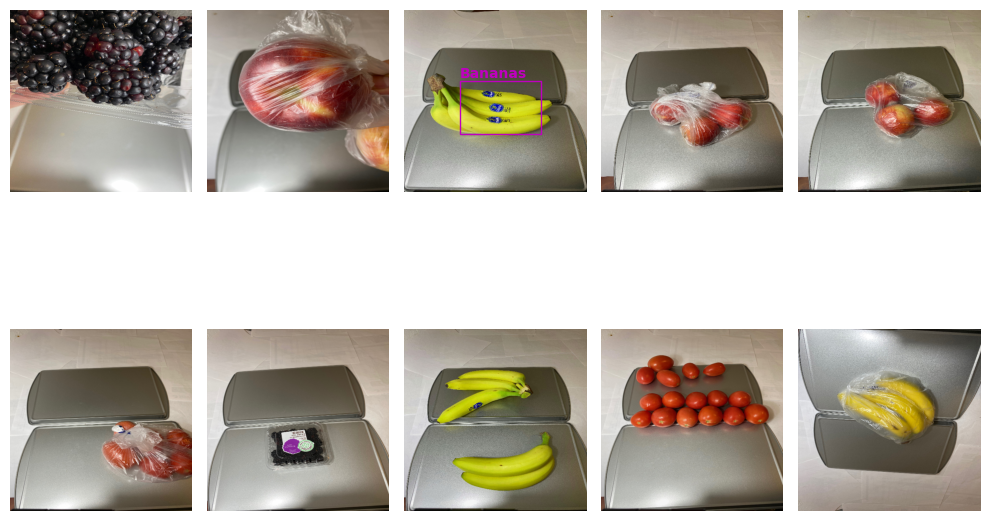

In [74]:
test_loader = torch.utils.data.DataLoader(test_ds, 10, collate_fn=collate_fn)
i = iter(test_loader)
batch = next(i)
model_test_1.eval()
pred = model_test_1(batch["image"].to(device)).cpu()
pred_decoded = decode_prediction_nms(pred, threshold=0.5)
visualize(batch["image"], pred_decoded)

## Эксперимент 2

Проведем эксперимент с другой моделью, в этот раз возьмем слои от ResNet50, обучим исходные слои с меньшим шагом, а новые - с большим

In [23]:
class Detector(nn.Module):
    def __init__(self, C):
        super().__init__()
        model = torchvision.models.resnet50(weights=ResNet50_Weights.DEFAULT)
        self.rn = nn.Sequential(*list(model.children())[:-2])

        self.vgg = nn.Sequential(
           nn.Conv2d(in_channels=2048, out_channels=512, kernel_size=3, padding=1),
           nn.BatchNorm2d(num_features=512),
           nn.ReLU(),

           nn.Conv2d(in_channels=512, out_channels=128, kernel_size=3, padding=1),
           nn.BatchNorm2d(num_features=128),
           nn.ReLU(),

           nn.Conv2d(in_channels=128, out_channels=32, kernel_size=3, padding=1),
           nn.BatchNorm2d(num_features=32),
           nn.ReLU(),

           nn.Conv2d(in_channels=32, out_channels=5+C, kernel_size=3, padding=1),
           nn.BatchNorm2d(num_features=5+C),
           nn.Sigmoid(),
           
        )

    def forward(self, img):
        x = self.rn(img)
        x = self.vgg(x)
        return x

In [24]:
try:
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.mps.is_available():
        device =torch.device("mps")
    else:
        device = torch.device("cpu")
except AttributeError:
    device = torch.device("cpu")

device

device(type='mps')

Обучаем модельку

In [25]:
LR_BACKBONE=1e-5
LR_HEAD=1e-3
EPOCHS = 1
BATCH_SIZE = 10
C = 10

In [26]:
torch.manual_seed(21)
model_test_2 = Detector(C).to(device)

log_file = new_log_file()

opt = torch.optim.Adam([
    {'params': model_test_2.rn.parameters(), 'lr': LR_BACKBONE},   
    {'params': model_test_2.vgg.parameters(), 'lr': LR_HEAD},
])

loss = special_loss
config_exp2={
        "model": "Detector",
        "backbone": "ResNet50",
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr_backbone": LR_BACKBONE,
        "lr_head": LR_HEAD,
        "seed": 21,
        "loss": loss.__class__.__name__,
        "architecture": str(model_test_2),
        "optimizer": opt.__class__.__name__,
        "task": "detection",
}

loader = torch.utils.data.DataLoader(train_ds, BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_ds, 10, collate_fn=collate_fn, shuffle=True)

run_exp2 = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name="cnn_detector_model_test_2", config=config_exp2)
m = train_model(model_test_2, loader, val_loader, loss, opt, EPOCHS, model_name="ResNet")
save_results(m, "test", loader, test_loader, log_file, run_exp2)
run_exp2.finish()

KeyboardInterrupt: 

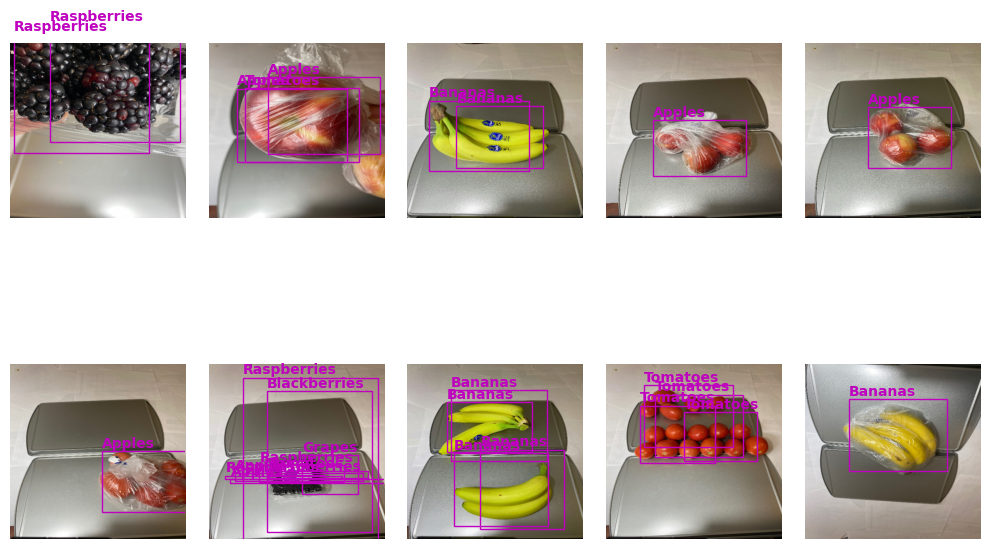

In [36]:
test_loader = torch.utils.data.DataLoader(test_ds, 10, collate_fn=collate_fn)
i = iter(test_loader)
batch = next(i)
model_test_2.eval()
pred = model_test_2(batch["image"].to(device)).cpu()
pred_decoded = decode_prediction_nms(pred, threshold=0.6)
visualize(batch["image"], pred_decoded)

## Эксперимент 3

Попробуем использовать уже проверенную архитектуру - YOLO из библиотеки ultralytics.

In [22]:
yolo_data_dir = 'dataset'

In [36]:
C = 10
yolo_config = {
    'path': os.path.abspath(yolo_data_dir),
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': C, 
    'names': list(class_labels.values())
}

with open(os.path.join(yolo_data_dir, 'data.yaml'), 'w', encoding='utf-8') as f:
    yaml.dump(yolo_config, f, allow_unicode=True)

print(yaml.dump(yolo_config, allow_unicode=True))

names:
- Bananas
- Bananas
- Blackberries
- Raspberries
- Grapes
- Grapes
- Tomatoes
- Tomatoes
- Apples
- Apples
nc: 10
path: c:\Users\Polina\Downloads\гп5\dataset
test: test/images
train: train/images
val: val/images



In [37]:
from ultralytics import YOLO

EPOCHS = 2

run_yolo = wandb.init(
    project=WANDB_PROJECT, 
    entity=WANDB_ENTITY, 
    name="yolov8_experiment",
    config={
        "model": "yolov8n",
        "epochs": EPOCHS,
        "imgsz": 512,
        "batch": 16,
        "data": "dataset/data.yaml"
    }
)

model_yolo = YOLO('yolov8n.pt')

results = model_yolo.train(
    data=os.path.join(yolo_data_dir, 'data.yaml'),
    epochs=EPOCHS,
    imgsz=512,
    batch=16,
    device='mps',  
    workers=0,
    patience=10,
    project='yolo_experiment',
    name='yolov8_fruits',
    exist_ok=True,
    verbose=True,
    seed=21, 
    save_period=1,
)

print(f"Лучшая модель: {results.save_dir}/weights/best.pt")

New https://pypi.org/project/ultralytics/8.4.68 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.64  Python-3.11.0 torch-2.12.0+cpu CPU (AMD Ryzen 7 5800H with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo

In [40]:
df = pd.read_csv(f"{results.save_dir}/results.csv")
df.columns = df.columns.str.strip() 
print(df[["epoch", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]].to_string())


   epoch  metrics/mAP50(B)  metrics/mAP50-95(B)
0      1           0.84714              0.64050
1      2           0.92911              0.73776


In [41]:
for i, row in df.iterrows():
    wandb.log({
        "yolo/map50": row["metrics/mAP50(B)"],
        "yolo/map": row["metrics/mAP50-95(B)"],
    })

In [42]:
best_epoch = df["metrics/mAP50(B)"].idxmax() 
print(f"Лучшая эпоха по mAP50: {best_epoch + 1}")
best_model = YOLO(f"{results.save_dir}/weights/epoch{best_epoch}.pt")


Лучшая эпоха по mAP50: 2


In [43]:
device ="mps"

In [44]:
def evaluate_yolo(mode, best_epoch):
    metrics = best_model.val(data=os.path.join(yolo_data_dir, 'data.yaml'),
                            split=mode,
                            imgsz=512,
                            batch=16,
                            device=device)

    print(mode)
    print(f"  mAP50:    {metrics.box.map50:.4f}")
    print(f"  mAP50-95: {metrics.box.map:.4f}")


    logging.info(
                f"Эпоха {best_epoch} | "
                f"{mode} Map: {metrics.box.map} | "
                f"{mode} Map50: {metrics.box.map50}"
            )

    return ({
        "dataset": mode,
        f"yolo/map50": metrics.box.map50,
        f"yolo/map": metrics.box.map,
    })

In [45]:
log_file = new_log_file()
train_metrics = evaluate_yolo('train', best_epoch+1)
test_metrics = evaluate_yolo('test', best_epoch+1)
metric_keys = list(train_metrics.keys())

Ultralytics 8.4.64  Python-3.11.0 torch-2.12.0+cpu CPU (AMD Ryzen 7 5800H with Radeon Graphics)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 955.1364.6 MB/s, size: 1183.9 KB)
val: Scanning C:\Users\Polina\Downloads\гп5\dataset\train\labels.cache... 2155 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2155/2155  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 135/135 1.6s/it 3:301.5ss
                   all       2155       2715      0.873      0.883      0.944      0.758
               Bananas        234        234          1      0.988      0.995      0.858
               Bananas        249        313      0.926       0.99      0.984      0.886
          Blackberries         94         94      0.714          1       0.97      0.667
           Raspberries        119        119          1      0.995      0.995      0.727
                

In [46]:
table = wandb.Table(columns=metric_keys)
table.add_data(*[train_metrics[i] for i in metric_keys])
table.add_data(*[test_metrics[i] for i in metric_keys])
wandb.log({'results': table})
artifact = wandb.Artifact(name='yolo8n', type="model", description="Тест логгирования модели: yolo8n")
artifact.add_file(f"{results.save_dir}/weights/epoch{best_epoch}.pt")
artifact.add_file(log_file)
run_yolo.log_artifact(artifact) 


<Artifact yolo8n>

In [47]:
run_yolo.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


yolo/map,▁█
yolo/map50,▁█
yolo/map,0.73776
yolo/map50,0.92911


In [48]:
def predict_and_visualize_yolo(model, image_path):
    results = model(image_path)
    result = results[0]
    img = result.orig_img
    boxes = result.boxes
    
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img)
    ax.axis('off')
    
    if boxes is not None:
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf = box.conf[0].item()
            cls = int(box.cls[0].item())
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                                 fill=False, edgecolor='red', linewidth=2)
            ax.add_patch(rect)
            
            label = f"{class_labels[cls]} ({conf:.2f})"
            ax.text(x1, y1-5, label, color='red', fontsize=10, 
                   fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))
    plt.show()

test_images = list(Path('dataset/test/images').glob('*.jpg'))[:3]
for img_path in test_images:
    predict_and_visualize_yolo(best_model, str(img_path))

image 1/1 c:\Users\Polina\Downloads\5\dataset\test\images\0_0_apple_wb_7.jpg: 512x384 1 Apples, 57.2ms
Speed: 4.5ms preprocess, 57.2ms inference, 2.2ms postprocess per image at shape (1, 3, 512, 384)


<Figure size 1000x1000 with 1 Axes>


image 1/1 c:\Users\Polina\Downloads\5\dataset\test\images\0_4_apple_wb_7.jpg: 512x384 1 Apples, 41.9ms
Speed: 4.7ms preprocess, 41.9ms inference, 6.1ms postprocess per image at shape (1, 3, 512, 384)


<Figure size 1000x1000 with 1 Axes>


image 1/1 c:\Users\Polina\Downloads\5\dataset\test\images\100_6_grapes_wob_7.jpg: 512x384 2 Grapess, 38.4ms
Speed: 3.0ms preprocess, 38.4ms inference, 6.8ms postprocess per image at shape (1, 3, 512, 384)


<Figure size 1000x1000 with 1 Axes>

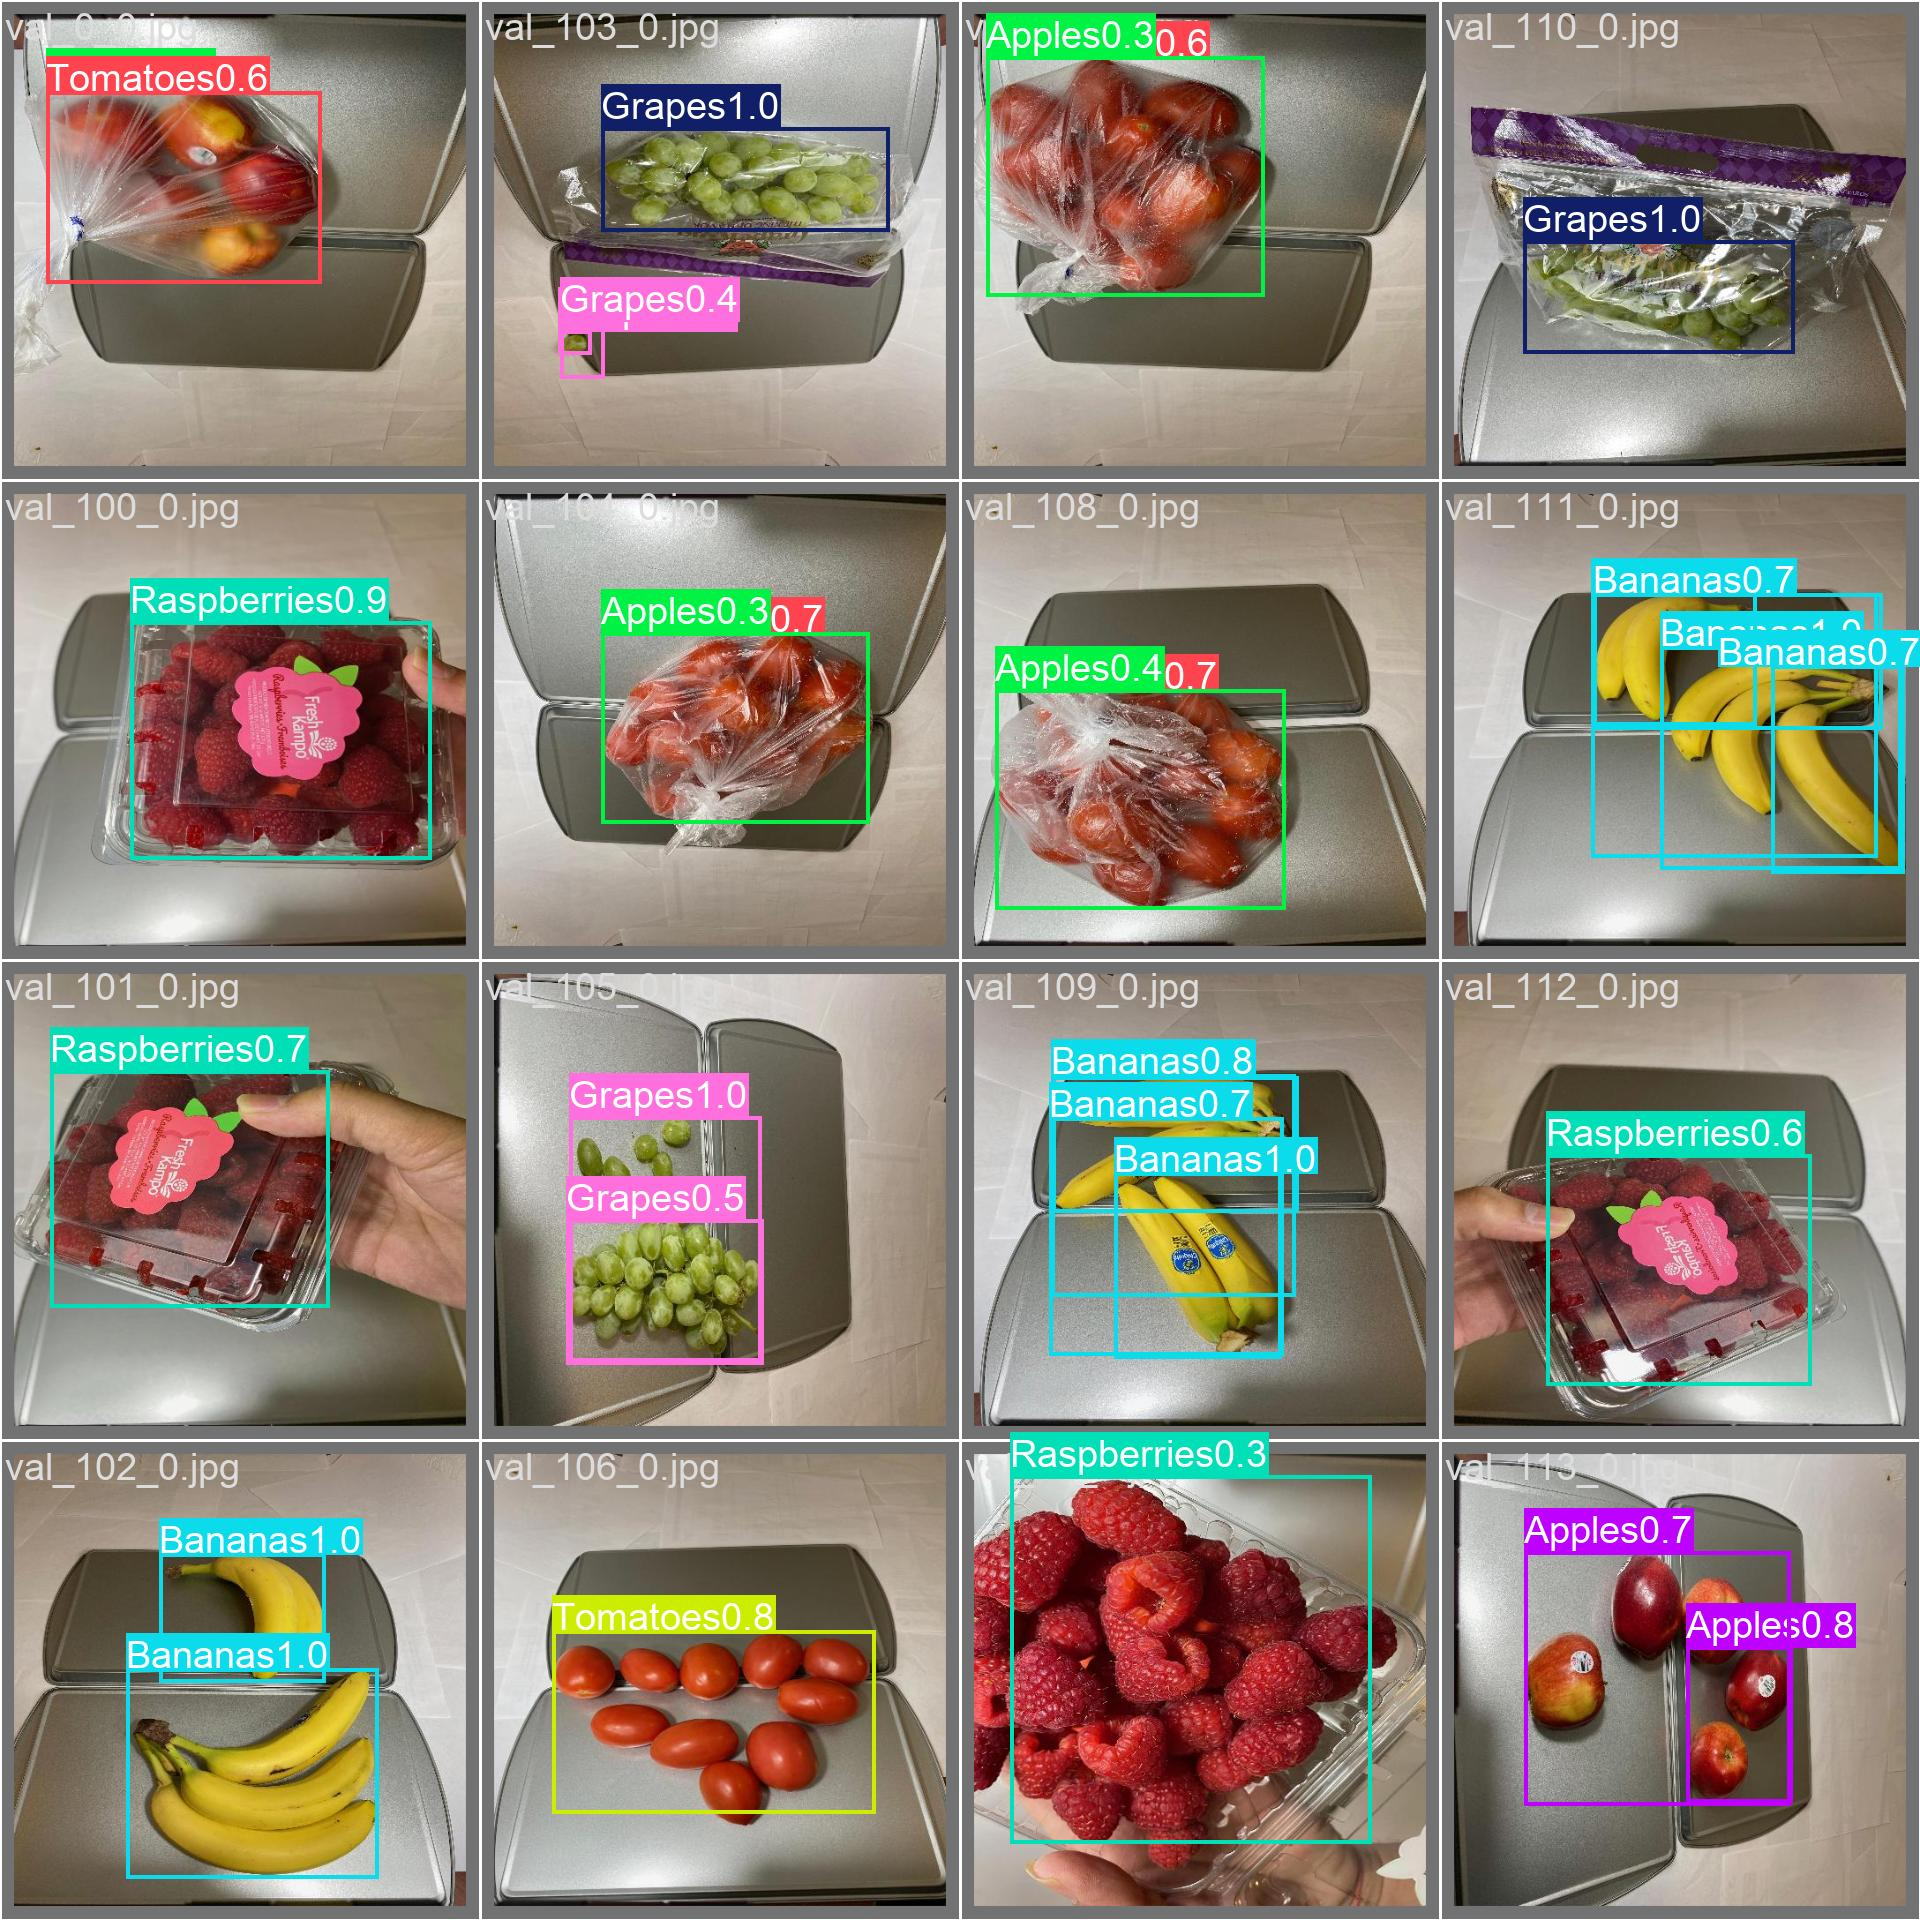

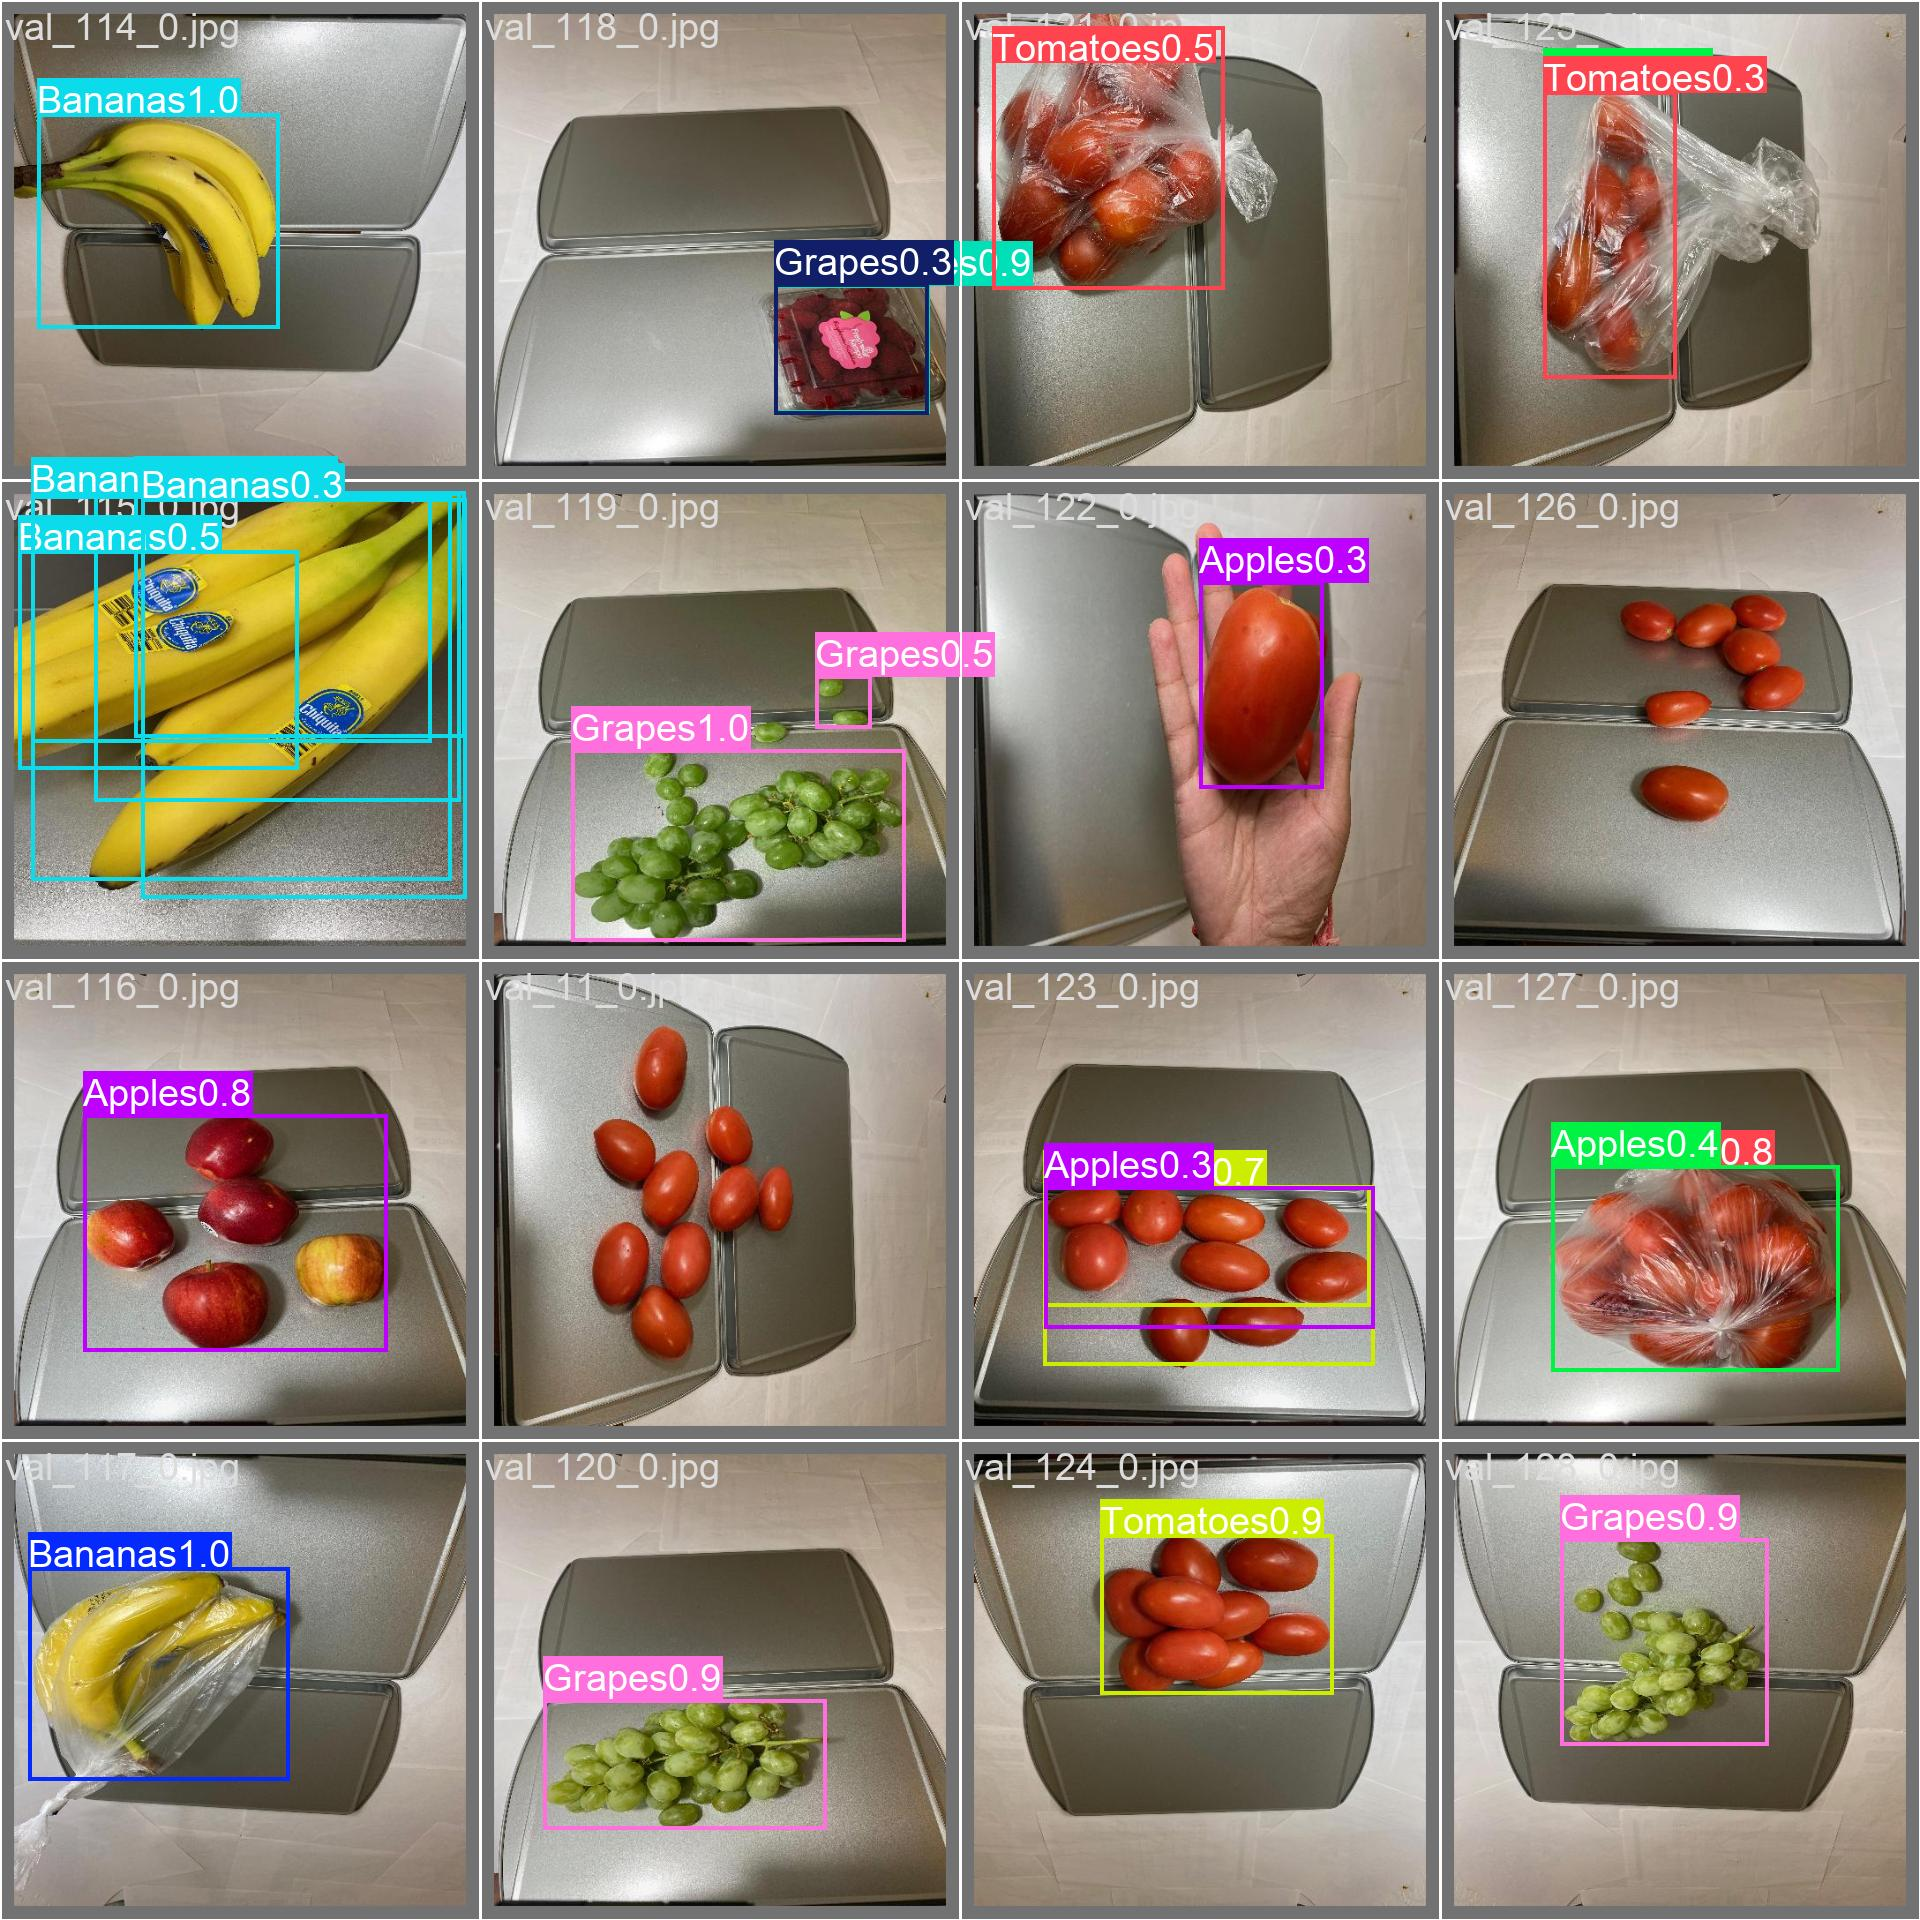

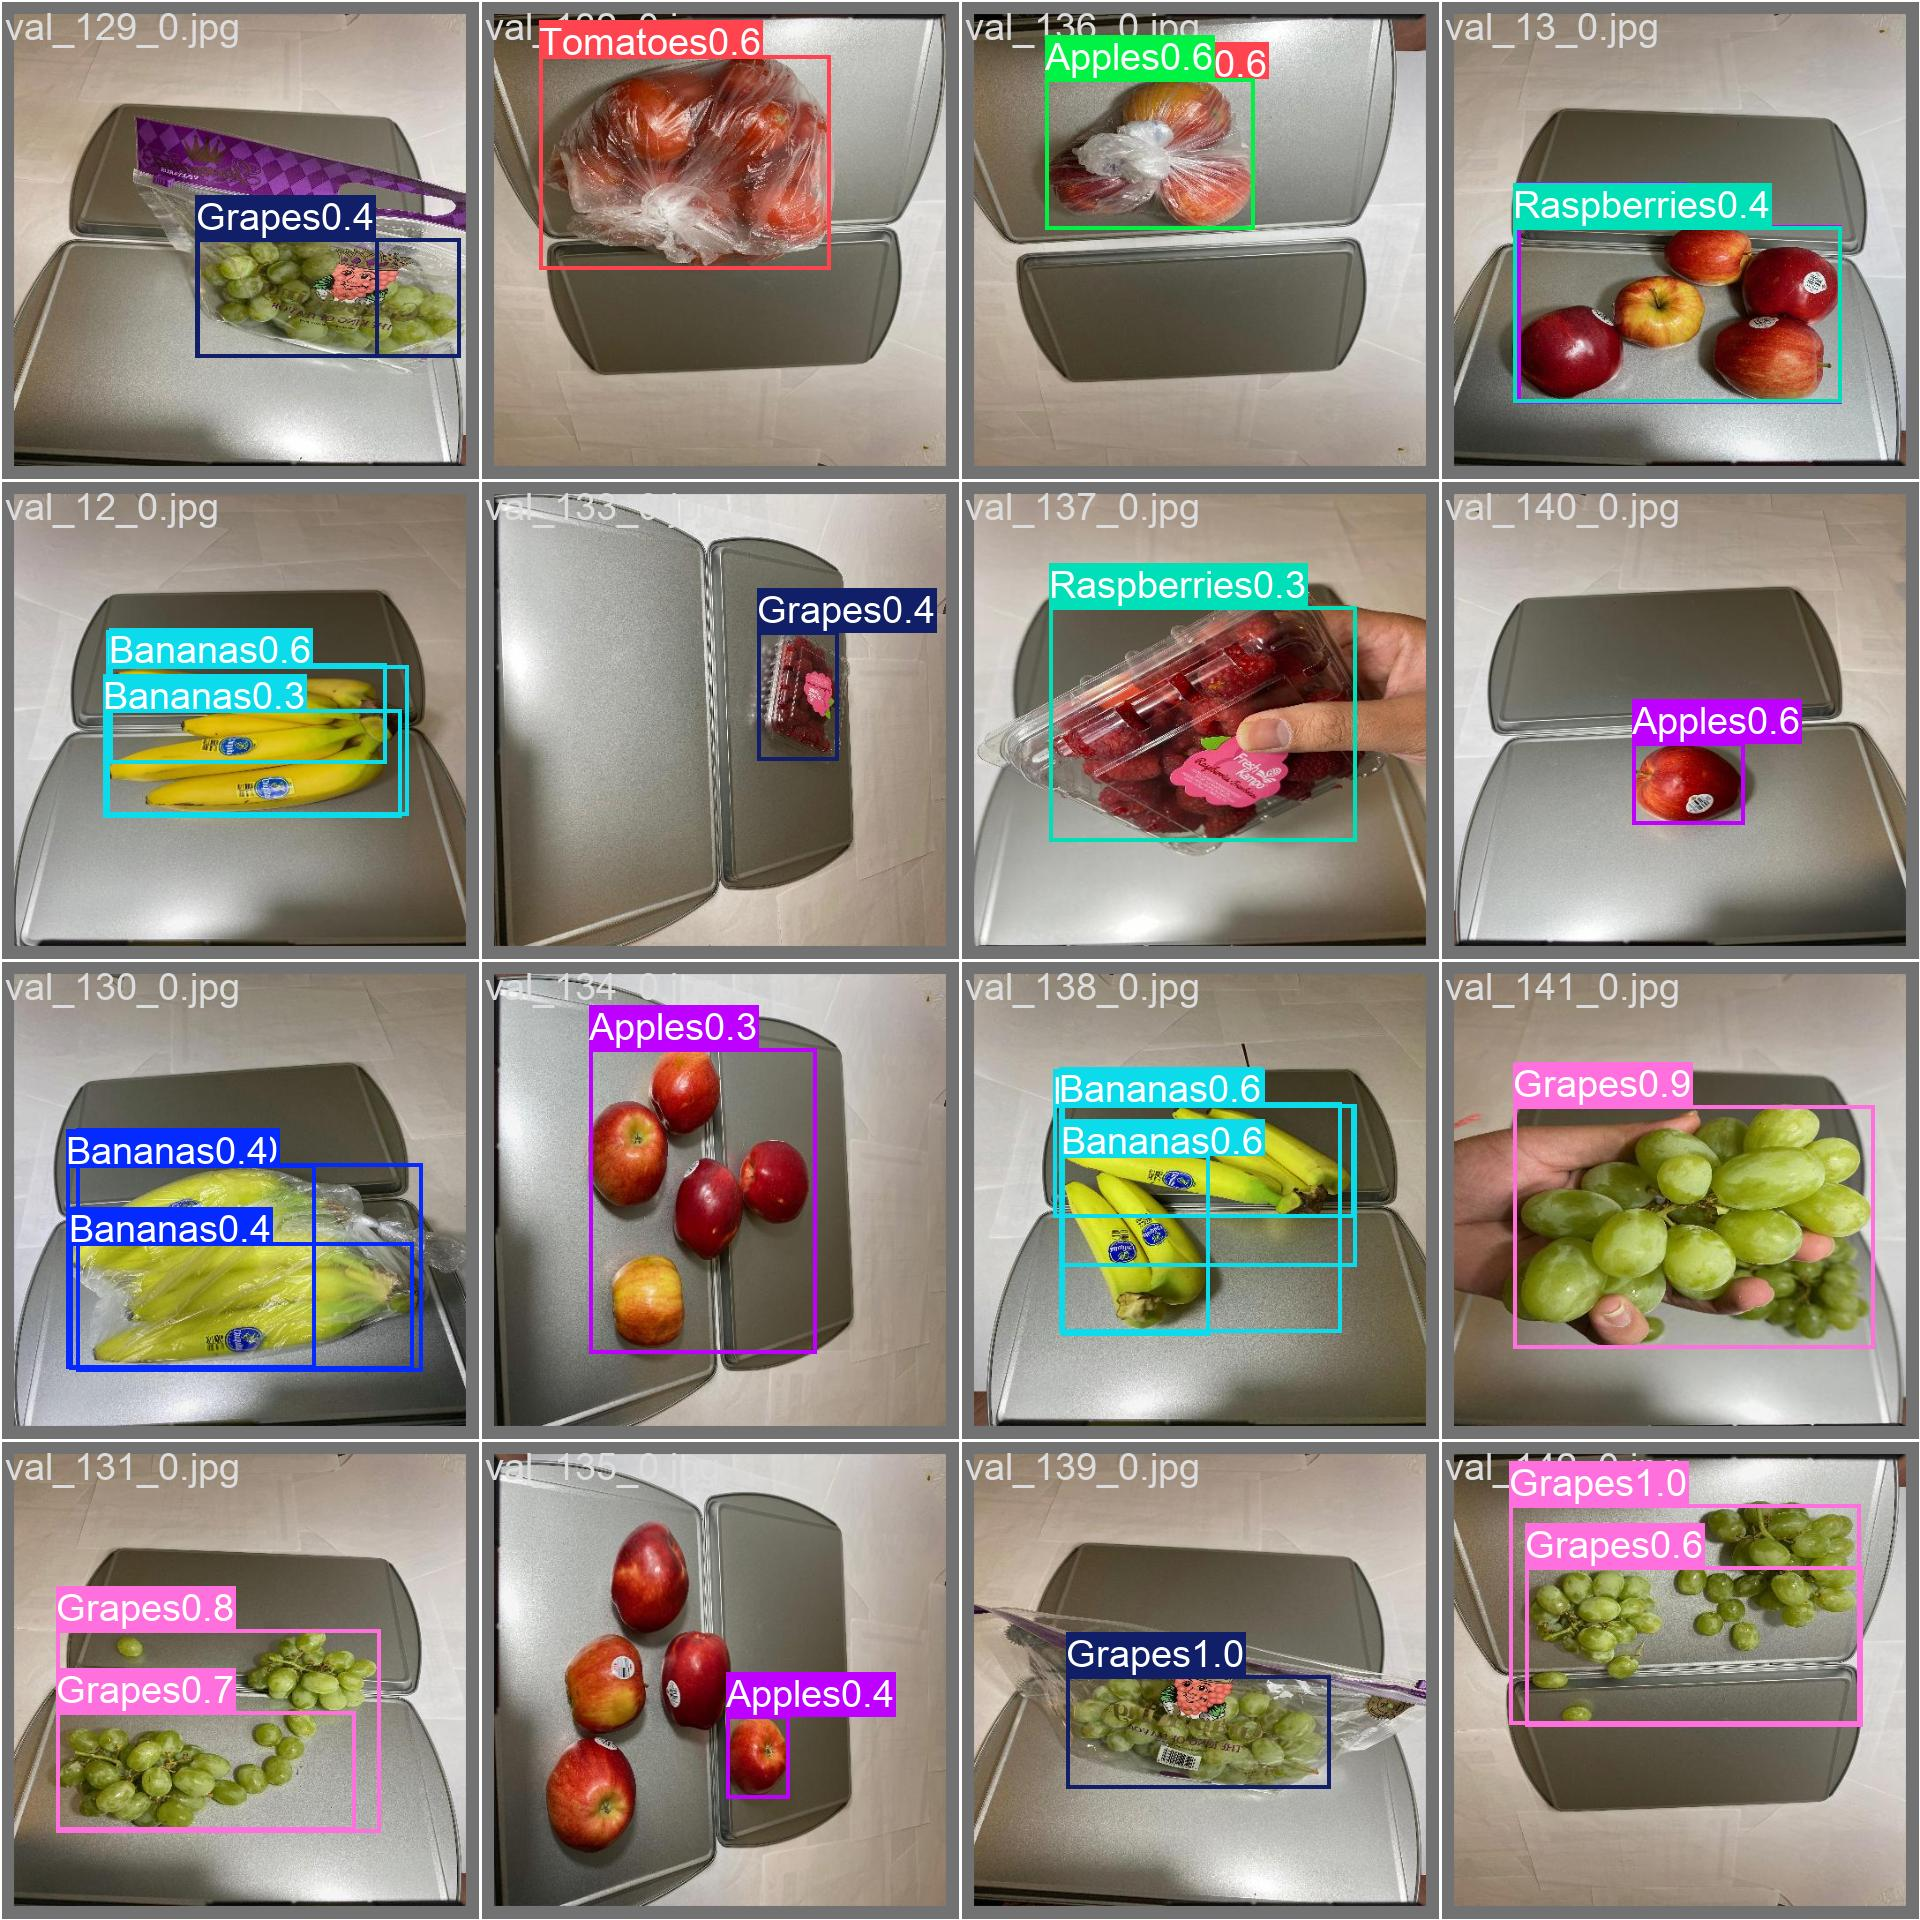

In [51]:
from IPython.display import Image, display

for imageName in glob.glob("./runs/detect/val/*.jpg"):
    if "pred" in imageName:
        display(Image(filename=imageName))